<a href="https://colab.research.google.com/github/hadilhorchani/neuroboundary/blob/main/nn_decision_boundary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from IPython.display import Image, display

np.random.seed(42)

X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

In [11]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42)
y_tr = y_tr.reshape(-1, 1)
y_te = y_te.reshape(-1, 1)

In [12]:
class NeuralNet:
    def __init__(self, n_in=2, n_hidden=16, lr=0.5):
        self.W1 = np.random.randn(n_in, n_hidden) * 0.5
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, 1) * 0.5
        self.b2 = np.zeros((1, 1))
        self.lr = lr

    def forward(self, X):
        self.A1 = np.tanh(X @ self.W1 + self.b1)              # hidden layer
        self.A2 = 1 / (1 + np.exp(-(self.A1 @ self.W2 + self.b2)))  # sigmoid output
        return self.A2

    def backward(self, X, y):
        m = X.shape[0]
        dZ2 = self.A2 - y                                     # BCE + sigmoid gradient
        dW2 = self.A1.T @ dZ2 / m
        db2 = dZ2.sum(axis=0, keepdims=True) / m
        dZ1 = (dZ2 @ self.W2.T) * (1 - self.A1 ** 2)          # tanh derivative
        dW1 = X.T @ dZ1 / m
        db1 = dZ1.sum(axis=0, keepdims=True) / m
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def loss(self, X, y):
        p = np.clip(self.forward(X), 1e-9, 1 - 1e-9)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    def predict(self, X):
      return (self.forward(X) > 0.5).astype(int)


In [13]:
net = NeuralNet(n_hidden=16, lr=0.5)

xx, yy = np.meshgrid(np.linspace(-2, 3, 150), np.linspace(-1.5, 2, 150))
grid = np.c_[xx.ravel(), yy.ravel()]

EPOCHS, EVERY = 1500, 25
frames = []

for epoch in range(EPOCHS + 1):
    if epoch % EVERY == 0:
        zz = net.forward(grid).reshape(xx.shape)
        acc = (net.predict(X_te) == y_te).mean()
        frames.append((epoch, zz, net.loss(X_tr, y_tr), acc))
    net.forward(X_tr)
    net.backward(X_tr, y_tr)

print(f"Final test accuracy: {frames[-1][3]:.1%}")

Final test accuracy: 91.0%


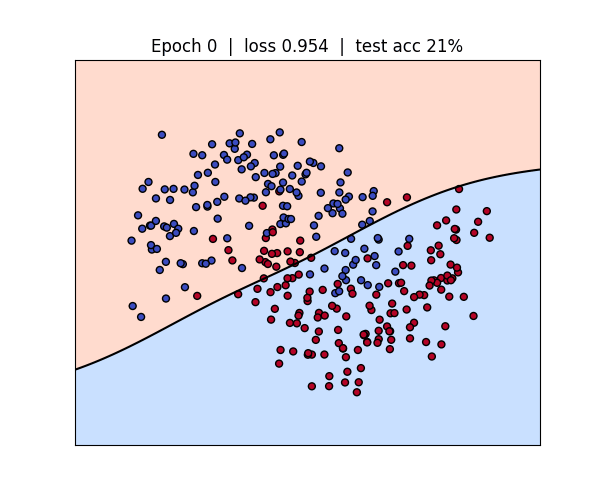

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

def draw(i):
    ax.clear()
    epoch, zz, loss, acc = frames[i]
    ax.contourf(xx, yy, zz, levels=[0, 0.5, 1], colors=["#bcd9ff", "#ffd2c2"], alpha=0.8)
    ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr.ravel(), cmap="coolwarm", edgecolors="k", s=25)
    ax.set_title(f"Epoch {epoch}  |  loss {loss:.3f}  |  test acc {acc:.0%}")
    ax.set_xticks([]); ax.set_yticks([])

anim = FuncAnimation(fig, draw, frames=len(frames), interval=100)
anim.save("decision_boundary.gif", writer=PillowWriter(fps=10))
plt.close(fig)
display(Image("decision_boundary.gif"))

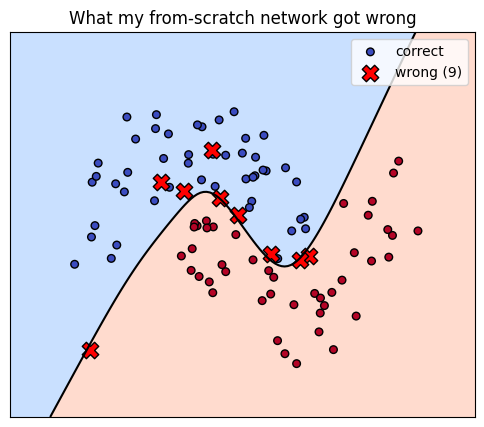

In [6]:
pred = net.predict(X_te).ravel()
wrong = pred != y_te.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
zz = net.forward(grid).reshape(xx.shape)
ax.contourf(xx, yy, zz, levels=[0, 0.5, 1], colors=["#bcd9ff", "#ffd2c2"], alpha=0.8)
ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=1.5)
ax.scatter(X_te[~wrong, 0], X_te[~wrong, 1], c=y_te.ravel()[~wrong], cmap="coolwarm",
           edgecolors="k", s=30, label="correct")
ax.scatter(X_te[wrong, 0], X_te[wrong, 1], marker="X", c="red", edgecolors="k",
           s=140, label=f"wrong ({wrong.sum()})")
ax.legend()
ax.set_title("What my from-scratch network got wrong")
ax.set_xticks([]); ax.set_yticks([])
plt.savefig("what_it_got_wrong.png", dpi=200, bbox_inches="tight")
plt.show()
